<a href="https://colab.research.google.com/github/enriquefroes/reforcos-galo-cruzeiro-2026/blob/main/notebooks/03_custo_beneficio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_reforcos_galo_cruzeiro'
except ImportError:
    BASE = './analise_reforcos_galo_cruzeiro'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
for arq in ['transferencias.csv', 'estatisticas.csv', 'pares.csv']:
    if not os.path.exists(os.path.join(DADOS, arq)):
        raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
transf = pd.read_csv(os.path.join(DADOS, 'transferencias.csv'))
est = pd.read_csv(os.path.join(DADOS, 'estatisticas.csv'))
pares = pd.read_csv(os.path.join(DADOS, 'pares.csv'))

PESOS = {'nota': 0.5, 'metricas': 0.3, 'titularidade': 0.2}
MIN_MINUTOS = 450
GRUPO = {'ATA': 'Ataque', 'PD/PE': 'Ataque', 'MC': 'Meio-campo', 'MEI': 'Meio-campo',
         'LD': 'Laterais', 'LE': 'Laterais', 'ZAG': 'Zagueiros', 'GOL': 'Goleiros'}
METRICAS = {
    'Ataque':     ['GA_90', 'xGxA_90', 'passes_decisivos_90', 'dribles_certos_90'],
    'Meio-campo': ['GA_90', 'passes_decisivos_90', 'passes_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Laterais':   ['GA_90', 'passes_decisivos_90', 'cruzamentos_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Zagueiros':  ['desarmes_90', 'interceptacoes_90', 'chutes_bloqueados_90', 'duelos_aereos_vencidos_90', 'passes_certos_90'],
    'Goleiros':   ['gols_evitados_90', 'jogos_sem_sofrer_gol_pct'],
}
CORES_CLUBE = {'Atlético-MG': '#111111', 'Cruzeiro': '#1d4ed8'}
SIGLA = {'Atlético-MG': 'CAM', 'Cruzeiro': 'CRU'}

def percentil(s):
    """Posição relativa de 0 (pior) a 1 (melhor) dentro do grupo de referência."""
    s = s.dropna()
    if len(s) < 2:
        return pd.Series(0.5, index=s.index)
    return (s.rank(method='average') - 1) / (len(s) - 1)

def preparar(est, transf):
    d = est.merge(transf[['clube', 'movimento', 'jogador', 'janela', 'operacao', 'valor_milhoes_euros']],
                  on=['clube', 'movimento', 'jogador'], how='left')
    n = d['minutos'] / 90
    d['grupo'] = d['posicao'].map(GRUPO)
    d['GA'] = d['gols'].fillna(0) + d['assistencias'].fillna(0)
    d['GA_90'] = d['GA'] / n
    d['xGxA_90'] = (d['xg'] + d['xa'].fillna(0)) / n
    for c in ['passes_decisivos', 'dribles_certos', 'passes_certos', 'cruzamentos_certos', 'desarmes',
              'interceptacoes', 'chutes_bloqueados', 'duelos_aereos_vencidos', 'gols_evitados']:
        d[c + '_90'] = d[c] / n
    d['jogos_sem_sofrer_gol_pct'] = d['jogos_sem_sofrer_gol'] / d['jogos']
    d['nota_media'] = (d['nota_sofascore'] + d['nota_fotmob']) / 2
    d['min_por_jogo'] = d['minutos'] / d['jogos']
    d['titularidade'] = (d['min_por_jogo'] / 90).clip(upper=1)

    ref = d['minutos'] >= MIN_MINUTOS
    d['p_nota'] = np.nan
    d['p_metricas'] = np.nan
    for g, cols in METRICAS.items():
        idx = d.index[ref & (d['grupo'] == g)]
        d.loc[idx, 'p_nota'] = percentil(d.loc[idx, 'nota_media'])
        pcts = pd.concat([percentil(d.loc[idx, c]) for c in cols], axis=1)
        d.loc[idx, 'p_metricas'] = pcts.mean(axis=1)
    d['score'] = 100 * (PESOS['nota'] * d['p_nota'] + PESOS['metricas'] * d['p_metricas']
                        + PESOS['titularidade'] * d['titularidade'])
    d.loc[~ref, 'score'] = np.nan
    d['n_ref_grupo'] = d['grupo'].map(d[ref].groupby('grupo').size())
    return d

df = preparar(est, transf)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
r = df[(df['movimento'] == 'chegada') & (df['entra_no_ranking'] == 'sim') & (df['grupo'] != 'Goleiros')].copy()
r['valor'] = r['valor_milhoes_euros'].fillna(0)
r['pago'] = r['valor'] > 0
r['euros_por_GA'] = np.where(r['pago'] & (r['GA'] > 0), r['valor'] / r['GA'], np.nan)
tabela = (r[['jogador', 'clube', 'grupo', 'operacao', 'valor', 'minutos', 'GA', 'euros_por_GA', 'nota_media', 'score']]
          .sort_values('valor', ascending=False).round(2))
tabela.to_csv(os.path.join(TAB, '03_custo_beneficio.csv'), index=False)
print('Índice médio · pagos:', round(r.loc[r['pago'], 'score'].mean(), 1), '| livres/empréstimos:', round(r.loc[~r['pago'], 'score'].mean(), 1))
tabela

Índice médio · pagos: 61.8 | livres/empréstimos: 47.7


,jogador,clube,grupo,operacao,valor,minutos,GA,euros_por_GA,nota_media,score
15,Gerson,Cruzeiro,Meio-campo,compra,27.00,3280,6.0,4.50,7.12,65.32
0,Alan Minda,Atlético-MG,Ataque,compra,7.00,1267,6.0,1.17,6.73,69.44
1,Mateo Cassierra,Atlético-MG,Ataque,compra,7.00,2109,9.0,0.78,6.67,48.15
20,Gabriel Rojas,Cruzeiro,Laterais,compra,5.25,832,0.0,NaN,6.58,34.47
7,Angelo Preciado,Atlético-MG,Laterais,compra,5.00,1366,1.0,5.00,6.74,53.20
4,Victor Hugo,Atlético-MG,Meio-campo,compra,2.15,2688,8.0,0.27,6.96,49.47
3,Fred,Atlético-MG,Meio-campo,compra,2.00,627,4.0,0.50,7.17,89.29
9,Vitor Hugo,Atlético-MG,Zagueiros,compra,1.00,2495,3.0,0.33,6.96,84.80
6,Maycon,Atlético-MG,Meio-campo,livre,0.00,2409,3.0,NaN,6.91,34.55
5,Kevin Castaño,Atlético-MG,Meio-campo,livre,0.00,541,1.0,NaN,6.95,40.61


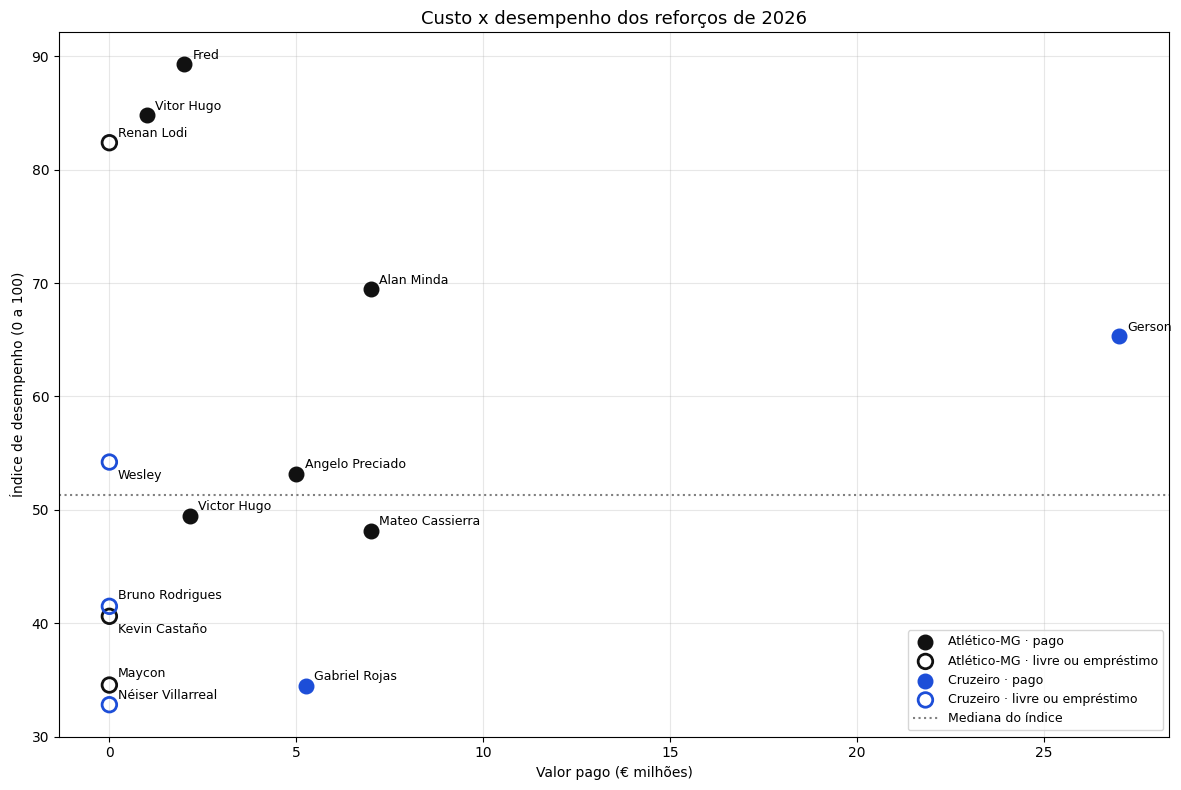

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/03a_custo_x_desempenho.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
for clube, g in r.groupby('clube'):
    cor = CORES_CLUBE[clube]
    ax.scatter(g.loc[g['pago'], 'valor'], g.loc[g['pago'], 'score'], s=110, color=cor, label=f'{clube} · pago', zorder=3)
    ax.scatter(g.loc[~g['pago'], 'valor'], g.loc[~g['pago'], 'score'], s=110, facecolors='none', edgecolors=cor,
               linewidths=2, label=f'{clube} · livre ou empréstimo', zorder=3)
ajustes = {'Kevin Castaño': (6, -12), 'Wesley': (6, -12), 'Maycon': (6, 6), 'Bruno Rodrigues': (6, 5)}
for _, row in r.iterrows():
    ax.annotate(row['jogador'], (row['valor'], row['score']), xytext=ajustes.get(row['jogador'], (6, 4)),
                textcoords='offset points', fontsize=9)
ax.axhline(r['score'].median(), ls=':', color='gray', label='Mediana do índice')
ax.set_xlabel('Valor pago (€ milhões)')
ax.set_ylabel('Índice de desempenho (0 a 100)')
ax.set_title('Custo x desempenho dos reforços de 2026', fontsize=13)
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
salvar('03a_custo_x_desempenho.png')

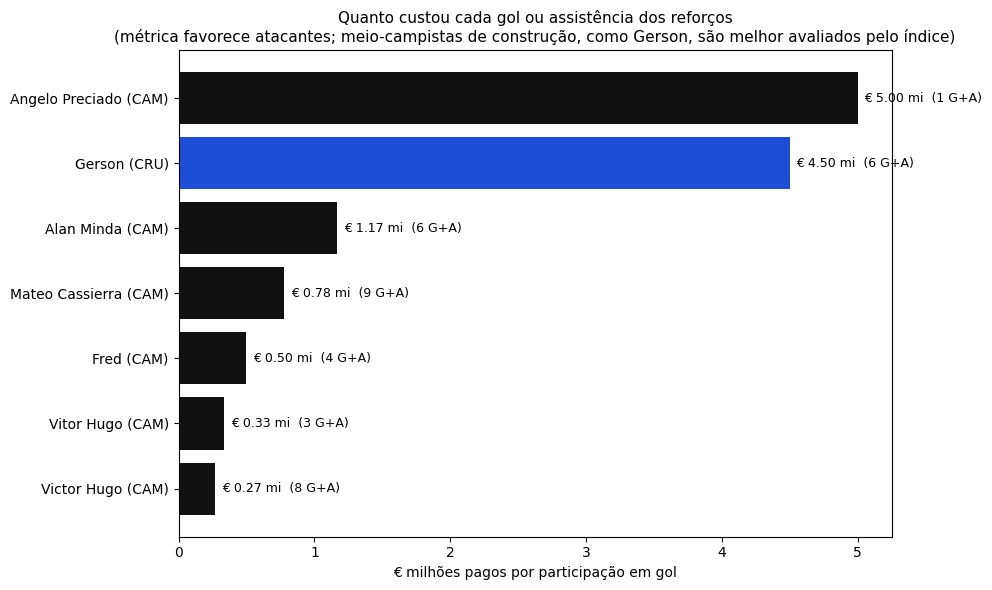

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/03b_euros_por_participacao_gol.png


In [4]:
t = r.dropna(subset=['euros_por_GA']).sort_values('euros_por_GA')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(t['jogador'] + ' (' + t['clube'].map(SIGLA) + ')', t['euros_por_GA'], color=t['clube'].map(CORES_CLUBE))
for i, (v, ga) in enumerate(zip(t['euros_por_GA'], t['GA'])):
    ax.text(v + 0.05, i, f'€ {v:.2f} mi  ({ga:.0f} G+A)', va='center', fontsize=9)
ax.set_xlabel('€ milhões pagos por participação em gol')
ax.set_title('Quanto custou cada gol ou assistência dos reforços\n'
             '(métrica favorece atacantes; meio-campistas de construção, como Gerson, são melhor avaliados pelo índice)', fontsize=11)
salvar('03b_euros_por_participacao_gol.png')